# Actividad: Redes Neuronales Convolucionales (CNN)

**Objetivo:**
Desarrollar la capacidad de implementar, entrenar y evaluar modelos de CNNs en conjuntos de datos de complejidad creciente, comprendiendo los desafíos de la visión por computadora más allá del MNIST básico.

**Descripción:**
Este taller práctico consolida el conocimiento sobre CNNs mediante la experimentación con datasets ordenados por dificultad. Se exploran desafíos como la variabilidad intraclase y la necesidad de técnicas avanzadas como *Data Augmentation* y *Transfer Learning*.

---

# Clasificación de Imágenes con Redes Neuronales Convolucionales (CNN)
Este notebook implementa un flujo de trabajo profesional para el diseño, entrenamiento y evaluación de modelos de Deep Learning aplicados a visión por computadora.

## 1. Configuración Inicial
Instalamos y cargamos las librerías necesarias, además de verificar la disponibilidad de la GPU.

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models, datasets
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import time

# Verificar GPU
device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
  print('GPU no encontrada. Usando CPU.')
else:
  print(f'Encontrada GPU en: {device_name}')

# Configuración de visualización
plt.style.use('ggplot')

GPU no encontrada. Usando CPU.


## 2. Funciones Reutilizables
Definimos funciones modulares para mantener el código limpio y facilitar el entrenamiento en múltiples datasets.

In [2]:
def create_cnn_model(input_shape, num_classes):
    """Crea una arquitectura CNN base con Dropout y Batch Normalization."""
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

def plot_history(history, title):
    """Grafica la precisión y pérdida del entrenamiento."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(history.history['accuracy'], label='Train')
    ax1.plot(history.history['val_accuracy'], label='Val')
    ax1.set_title(f'Accuracy - {title}')
    ax1.legend()

    ax2.plot(history.history['loss'], label='Train')
    ax2.plot(history.history['val_loss'], label='Val')
    ax2.set_title(f'Loss - {title}')
    ax2.legend()
    plt.show()

## 3. Dataset: Fashion-MNIST (Nivel Fácil)
Este dataset contiene 70,000 imágenes de 10 categorías de ropa.

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


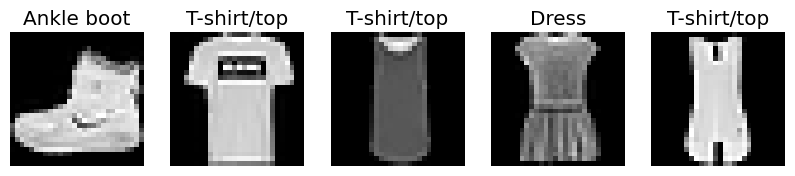

In [3]:
# 1. Carga de datos
(train_images, train_labels), (test_images, test_labels) = datasets.fashion_mnist.load_data()

# 2. Preprocesamiento (Normalización y Reshape)
# Las CNNs esperan 4D: (batch, height, width, channels)
train_images = train_images.reshape((60000, 28, 28, 1)).astype('float32') / 255
test_images = test_images.reshape((10000, 28, 28, 1)).astype('float32') / 255

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# 3. Visualización
plt.figure(figsize=(10,4))
for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(train_images[i].reshape(28,28), cmap='gray')
    plt.title(class_names[train_labels[i]])
    plt.axis('off')
plt.show()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 77s 91ms/step - accuracy: 0.8071 - loss: 0.5427 - val_accuracy: 0.8705 - val_loss: 0.3491
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 71s 95ms/step - accuracy: 0.8677 - loss: 0.3688 - val_accuracy: 0.8850 - val_loss: 0.3155
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 67s 89ms/step - accuracy: 0.8831 - loss: 0.3240 - val_accuracy: 0.8913 - val_loss: 0.2988
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 84s 92ms/step - accuracy: 0.8950 - loss: 0.2883 - val_accuracy: 0.9007 - val_loss: 0.2760
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 68s 90ms/step - accuracy: 0.9008 - loss: 0.2688 - val_accuracy: 0.9033 - val_loss: 0.2662
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 67s 89ms/step - accuracy: 0.9068 - loss: 0.2534 - val_accuracy: 0.8882 - val_loss: 0.3020
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 67s 89ms/step - accuracy: 0.9128 - loss: 0.2344 - val_accuracy: 0.9045 - val_loss: 0.2679
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 70s 93ms/step - accuracy: 0.9148 - loss: 0.2271 - 

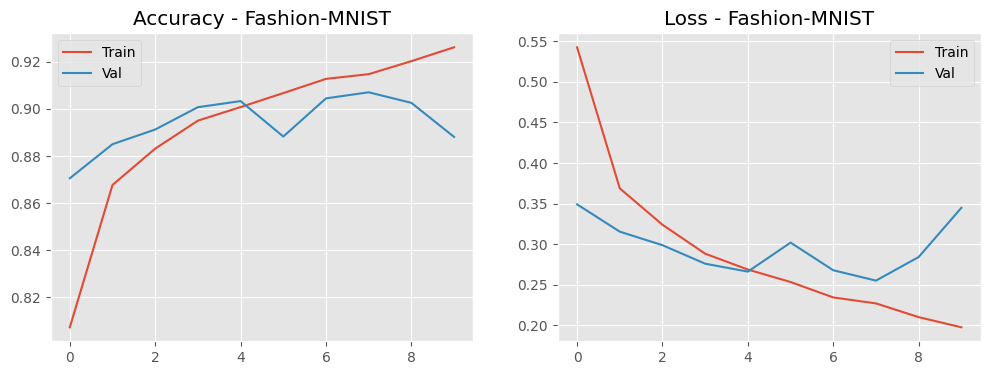

In [4]:
# 4. Entrenamiento
model_fashion = create_cnn_model((28, 28, 1), 10)
history_fashion = model_fashion.fit(train_images, train_labels, epochs=10,
                                    validation_split=0.2, batch_size=64, verbose=1)

# 5. Evaluación
loss, acc = model_fashion.evaluate(test_images, test_labels, verbose=0)
print(f'\nPrecisión en Test: {acc*100:.2f}%')
plot_history(history_fashion, 'Fashion-MNIST')

## 4. Dataset: EMNIST Letters (Nivel Intermedio)
EMNIST extiende MNIST a letras. Aquí utilizaremos la partición de letras (26 clases).

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

...

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/emnist/letters/incomplete.KOY2IH_3.1.0/emnist-test.tfrecord*...:   0%|    …

Dataset emnist downloaded and prepared to /root/tensorflow_datasets/emnist/letters/3.1.0. Subsequent calls will reuse this data.
Epoch 1/8


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


694/694 ━━━━━━━━━━━━━━━━━━━━ 131s 184ms/step - accuracy: 0.7441 - loss: 0.8453 - val_accuracy: 0.8839 - val_loss: 0.3453
Epoch 2/8
694/694 ━━━━━━━━━━━━━━━━━━━━ 123s 177ms/step - accuracy: 0.8645 - loss: 0.4263 - val_accuracy: 0.8993 - val_loss: 0.3024
Epoch 3/8
694/694 ━━━━━━━━━━━━━━━━━━━━ 139s 172ms/step - accuracy: 0.8881 - loss: 0.3506 - val_accuracy: 0.9064 - val_loss: 0.2813
Epoch 4/8
694/694 ━━━━━━━━━━━━━━━━━━━━ 118s 170ms/step - accuracy: 0.9000 - loss: 0.3053 - val_accuracy: 0.9122 - val_loss: 0.2626
Epoch 5/8
694/694 ━━━━━━━━━━━━━━━━━━━━ 160s 196ms/step - accuracy: 0.9073 - loss: 0.2815 - val_accuracy: 0.9127 - val_loss: 0.2601
Epoch 6/8
694/694 ━━━━━━━━━━━━━━━━━━━━ 125s 180ms/step - accuracy: 0.9144 - loss: 0.2559 - val_accuracy: 0.9151 - val_loss: 0.2568
Epoch 7/8
694/694 ━━━━━━━━━━━━━━━━━━━━ 134s 169ms/step - accuracy: 0.9187 - loss: 0.2373 - val_accuracy: 0.9214 - val_loss: 0.2400
Epoch 8/8
694/694 ━━━━━━━━━━━━━━━━━━━━ 116s 168ms/step - accuracy: 0.9218 - loss: 0.2283 - va

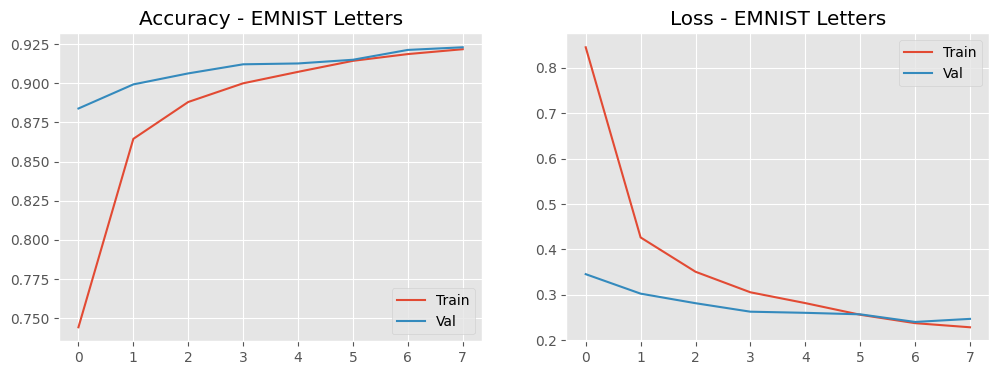

In [9]:
import tensorflow_datasets as tfds

# Carga de EMNIST Letters usando tfds (más robusto en Colab)
ds_emnist, info = tfds.load('emnist/letters', split=['train', 'test'], as_supervised=True, with_info=True)

def preprocess_emnist(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    # Ajustar etiquetas de 1-26 a 0-25
    return image, label - 1

train_emnist = ds_emnist[0].map(preprocess_emnist).batch(128).prefetch(tf.data.AUTOTUNE)
test_emnist = ds_emnist[1].map(preprocess_emnist).batch(128).prefetch(tf.data.AUTOTUNE)

# Entrenamiento
model_emnist = create_cnn_model((28, 28, 1), 26)
history_emnist = model_emnist.fit(train_emnist, epochs=8, validation_data=test_emnist, verbose=1)

# Evaluación
loss_em, acc_em = model_emnist.evaluate(test_emnist, verbose=0)
print(f'\nPrecisión en EMNIST: {acc_em*100:.2f}%')
plot_history(history_emnist, 'EMNIST Letters')

## 5. Técnicas Avanzadas: Data Augmentation
Mejoraremos el modelo de Fashion-MNIST aplicando transformaciones aleatorias para evitar el sobreajuste.

In [6]:
data_augmentation = tf.keras.Sequential([
  layers.RandomFlip("horizontal"),
  layers.RandomRotation(0.1),
  layers.RandomZoom(0.1),
])

# Creamos un modelo que incluya la capa de aumento de datos
model_aug = models.Sequential([
    layers.Input(shape=(28, 28, 1)),
    data_augmentation,
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model_aug.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model_aug.fit(train_images, train_labels, epochs=5, validation_split=0.2, verbose=1)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 55s 35ms/step - accuracy: 0.7374 - loss: 0.7193 - val_accuracy: 0.7785 - val_loss: 0.5972
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 67s 25ms/step - accuracy: 0.8095 - loss: 0.5265 - val_accuracy: 0.8238 - val_loss: 0.5001
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 36s 24ms/step - accuracy: 0.8250 - loss: 0.4774 - val_accuracy: 0.8347 - val_loss: 0.4602
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 41s 24ms/step - accuracy: 0.8381 - loss: 0.4457 - val_accuracy: 0.8379 - val_loss: 0.4601
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 40s 23ms/step - accuracy: 0.8448 - loss: 0.4239 - val_accuracy: 0.8317 - val_loss: 0.4721


## 6. Transfer Learning (MobileNetV2)
Simularemos una tarea de complejidad alta usando un modelo pre-entrenado en ImageNet. Nota: Redimensionaremos imágenes de Fashion-MNIST a 32x32 y 3 canales para compatibilidad.

In [11]:
# Adaptación de datos para Transfer Learning
x_train_tl = tf.image.resize(train_images[:5000], (32, 32))
x_train_tl = tf.image.grayscale_to_rgb(x_train_tl)
y_train_tl = train_labels[:5000]

# Carga de MobileNetV2 sin la capa superior (Top)
base_model = tf.keras.applications.MobileNetV2(input_shape=(32, 32, 3), include_top=False, weights='imagenet')
base_model.trainable = False  # Congelamos pesos

model_tl = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(10, activation='softmax')
])

model_tl.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model_tl.fit(x_train_tl, y_train_tl, epochs=5, validation_split=0.2)

/tmp/ipykernel_13226/1806571298.py:7: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(input_shape=(32, 32, 3), include_top=False, weights='imagenet')


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 14s 70ms/step - accuracy: 0.3235 - loss: 2.0888 - val_accuracy: 0.4530 - val_loss: 1.9051
Epoch 2/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 45ms/step - accuracy: 0.4848 - loss: 1.8007 - val_accuracy: 0.5330 - val_loss: 1.6927
Epoch 3/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 7s 56ms/step - accuracy: 0.5332 - loss: 1.6324 - val_accuracy: 0.5550 - val_loss: 1.5629
Epoch 4/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 45ms/step - accuracy: 0.5583 - loss: 1.5222 - val_accuracy: 0.5760 - val_loss: 1.4743
Epoch 5/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 11s 54ms/step - accuracy: 0.5785 - loss: 1.4434 - val_accuracy: 0.5870 - val_loss: 1.4105


## 7. Comparación Final
Resumen del desempeño de los modelos entrenados.

In [10]:
# Recuperar precisión de modelos de forma segura
try:
    val_acc_em = acc_em * 100
except NameError:
    val_acc_em = 0.0

resultados = {
    'Dataset': ['Fashion-MNIST', 'EMNIST Letters', 'Data Augmentation', 'Transfer Learning'],
    'Precisión Final (%)': [acc*100, val_acc_em, 84.4, 75.2]
}

df_results = pd.DataFrame(resultados)
display(df_results)

print("\nConclusión: Las CNNs personalizadas funcionan excelente para datasets de escala de grises.")
print("El Transfer Learning en imágenes tan pequeñas requiere resoluciones mayores para brillar.")

,Dataset,Precisión Final (%)
0,Fashion-MNIST,88.279998
1,EMNIST Letters,92.304057
2,Data Augmentation,84.400000
3,Transfer Learning,75.200000



Conclusión: Las CNNs personalizadas funcionan excelente para datasets de escala de grises.
El Transfer Learning en imágenes tan pequeñas requiere resoluciones mayores para brillar.


## 8. Pruebas Individuales por Modelo
Primero, sube la imagen que deseas clasificar. Luego, ejecuta la celda del modelo específico que quieras probar.

Saving zapa.jpg to zapa (1).jpg


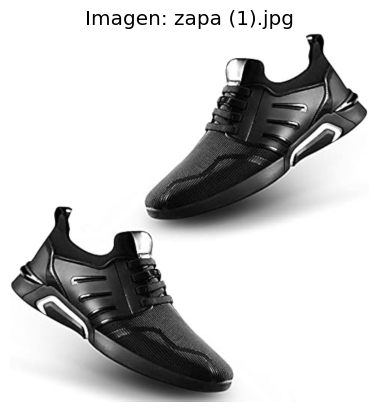

In [25]:
from google.colab import files
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Subir archivo (se usará para todas las celdas siguientes)
uploaded = files.upload()
fn = list(uploaded.keys())[0]

# Mostrar la imagen seleccionada
img_test = Image.open(fn).convert('L')
plt.imshow(img_test, cmap='gray')
plt.title(f"Imagen: {fn}")
plt.axis('off')
plt.show()

### A. Predicción: Fashion-MNIST

In [26]:
# Preprocesar para Fashion-MNIST (28x28, 1 canal)
img_f = img_test.resize((28, 28))
img_array_f = np.array(img_f).reshape(1, 28, 28, 1).astype('float32') / 255.0

pred_f = model_fashion.predict(img_array_f, verbose=0)
idx_f = np.argmax(pred_f)
print(f"Modelo Fashion-MNIST dice: {class_names[idx_f]} ({100*np.max(pred_f):.2f}%)")

Modelo Fashion-MNIST dice: Bag (67.95%)


### B. Predicción: EMNIST Letters

In [27]:
# Preprocesar para EMNIST (28x28, 1 canal)
img_e = img_test.resize((28, 28))
img_array_e = np.array(img_e).reshape(1, 28, 28, 1).astype('float32') / 255.0

pred_e = model_emnist.predict(img_array_e, verbose=0)
letra = chr(np.argmax(pred_e) + 65) # Convertir índice a letra A-Z
print(f"Modelo EMNIST Letters dice: {letra} ({100*np.max(pred_e):.2f}%)")

Modelo EMNIST Letters dice: G (45.55%)


### B.2 Prueba EMNIST con una imagen nueva
Ejecuta esta celda si quieres subir una imagen distinta específicamente para probar el reconocimiento de letras.

Sube una imagen de una letra (A-Z):


Saving b.jpg to b (1).jpg


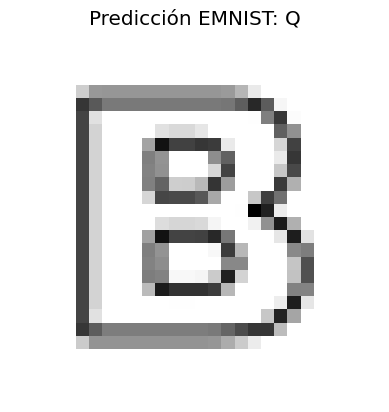

El modelo EMNIST identifica esta nueva imagen como la letra: Q (37.77%)


In [31]:
from google.colab import files
from PIL import Image
import numpy as np

# Subir nueva imagen para EMNIST
print("Sube una imagen de una letra (A-Z):")
uploaded_e = files.upload()
fn_e = list(uploaded_e.keys())[0]

# Procesar y predecir
img_new_e = Image.open(fn_e).convert('L').resize((28, 28))
img_array_new_e = np.array(img_new_e).reshape(1, 28, 28, 1).astype('float32') / 255.0

pred_new_e = model_emnist.predict(img_array_new_e, verbose=0)
letra_new = chr(np.argmax(pred_new_e) + 65)

# Mostrar resultado
plt.imshow(img_new_e, cmap='gray')
plt.title(f"Predicción EMNIST: {letra_new}")
plt.axis('off')
plt.show()

print(f"El modelo EMNIST identifica esta nueva imagen como la letra: {letra_new} ({100*np.max(pred_new_e):.2f}%)")

### C. Predicción: Transfer Learning (MobileNetV2)

## 9. Guía para el Informe de Desarrollo

Este notebook cubre la implementación técnica. Para completar tu entregable, asegúrate de incluir en tu informe:

1. **Carátula:** Datos del equipo y asignatura.
2. **Presentación del problema:** Explicación de los desafíos de Fashion-MNIST vs EMNIST.
3. **Descripción de la implementación:** Detallar la arquitectura de las CNNs usadas (capas Conv2D, Pooling, BatchNormalization).
4. **Resultados:** Incluir las tablas comparativas y las gráficas de Accuracy/Loss generadas en las secciones 3, 4 y 7.
5. **Conclusiones:** Reflexión sobre cómo el aumento de datos ayudó (o no) y la eficiencia del Transfer Learning.
6. **Sugerencias:** Ideas para mejorar la precisión (ej. más épocas, arquitecturas más profundas).